# Kunci Jawaban - Linear Regression

- **Dataset:** [Concrete Compressive Strength](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength)
- **Target:** `Concrete compressive strength`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan line plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [ ]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [ ]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [2]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Concrete Compressive Strength menggunakan ID dataset dari UCI.

In [3]:
concrete = fetch_ucirepo(id=165)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [4]:
X_raw = concrete.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [5]:
y_raw = concrete.data.targets.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL` agar mudah dipakai ulang di bagian berikutnya.

In [6]:
TARGET_COL = "Concrete compressive strength"

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df` agar mudah dicek di tahap EDA.

In [7]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [8]:
df.shape

(1030, 9)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **1030 baris** dan **9 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset memiliki **8 fitur** dan **1 target**, yaitu `Concrete compressive strength`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [9]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.000,0.000,0.000,162.000,2.500,1040.000,676.000,28,79.990
1,540.000,0.000,0.000,162.000,2.500,1055.000,676.000,28,61.890
2,332.500,142.500,0.000,228.000,0.000,932.000,594.000,270,40.270
3,332.500,142.500,0.000,228.000,0.000,932.000,594.000,365,41.050
4,198.600,132.400,0.000,192.000,0.000,978.400,825.500,360,44.300


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya, semua kolom yang terlihat berisi angka.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Tidak, dataset tidak membutuhkan encoding kategori karena seluruh kolom berupa data numerik.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Tipe data kolom terdiri dari **8 kolom float64** dan **1 kolom int64**.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak, semua kolom memiliki jumlah non-null yang sama dengan jumlah baris dataset, yaitu **1030 non-null**.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [12]:
df.isna().sum()

Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value. Semua kolom memiliki missing value **0**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Tidak perlu, karena dataset tidak memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [13]:
df.duplicated().sum()

np.int64(25)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Terdapat **25 baris duplikat penuh**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Baris duplikat perlu dihapus agar data tidak menghitung sampel yang sama lebih dari satu kali.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [14]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000,1030.000
mean,281.168,73.896,54.188,181.567,6.205,972.919,773.580,45.662,35.818
std,104.506,86.279,63.997,21.354,5.974,77.754,80.176,63.170,16.706
min,102.000,0.000,0.000,121.800,0.000,801.000,594.000,1.000,2.330
25%,192.375,0.000,0.000,164.900,0.000,932.000,730.950,7.000,23.710
50%,272.900,22.000,0.000,185.000,6.400,968.000,779.500,28.000,34.445
75%,350.000,142.950,118.300,192.000,10.200,1029.400,824.000,56.000,46.135
max,540.000,359.400,200.100,247.000,32.200,1145.000,992.600,365.000,82.600


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala antar fitur berbeda. Contohnya, `Cement`, `Coarse Aggregate`, dan `Fine Aggregate` bernilai ratusan, sedangkan `Superplasticizer` jauh lebih kecil.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [15]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah duplikat dihapus.

In [16]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah duplikat dihapus.

In [17]:
df_clean.shape

(1005, 9)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Setelah duplikat dihapus, dataset memiliki **1005 baris** dan **9 kolom**.

> Berapa jumlah baris yang berkurang dari dataset awal?

Jawaban: Jumlah baris berkurang sebanyak **25 baris**, dari 1030 menjadi 1005 baris.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat yang tersisa.

In [18]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak, jumlah duplikat setelah cleaning adalah **0**.

> Jelaskan kondisi dataset setelah duplikat dihapus.

Jawaban: Dataset sudah lebih bersih karena tidak ada baris duplikat penuh yang tersisa.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [19]:
df_clean[TARGET_COL].describe()

count   1005.000
mean      35.250
std       16.285
min        2.330
25%       23.520
50%       33.800
75%       44.870
max       82.600
Name: Concrete compressive strength, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **35.25 MPa**, nilai minimum **2.33 MPa**, dan nilai maksimum **82.60 MPa**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Rentang nilai target cukup lebar, sehingga kuat tekan beton pada dataset bervariasi dari rendah sampai tinggi.

### Buat histogram target

Gunakan histogram dengan garis KDE untuk melihat persebaran nilai target dan bentuk kurvanya.

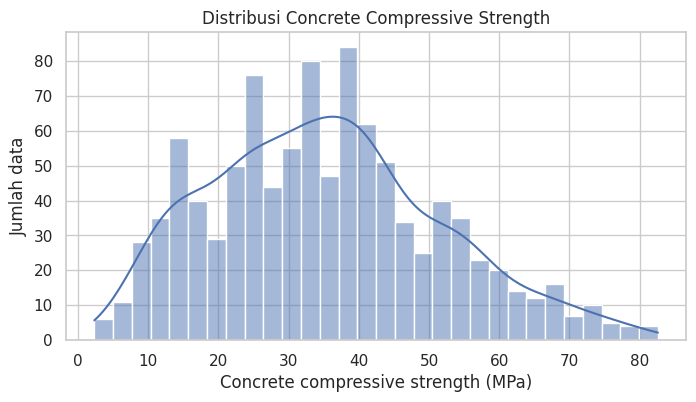

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Concrete Compressive Strength")
plt.xlabel("Concrete compressive strength (MPa)")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Sebagian besar nilai target muncul pada area rendah sampai menengah, terutama sekitar **20 sampai 45 MPa**.

> Apakah bentuk distribusinya mendekati lonceng sempurna atau condong ke salah satu sisi?

Jawaban: Distribusinya tidak berbentuk lonceng sempurna dan masih memiliki ekor ke arah nilai kuat tekan yang lebih tinggi.

### Hitung korelasi fitur dengan target

Hitung korelasi setiap fitur terhadap target.

In [21]:
corr_with_target = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_with_target

Cement                0.488
Superplasticizer      0.344
Age                   0.337
Blast Furnace Slag    0.103
Fly Ash              -0.081
Coarse Aggregate     -0.145
Fine Aggregate       -0.186
Water                -0.270
Name: Concrete compressive strength, dtype: float64

> Berdasarkan output korelasi, fitur apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `Cement`, `Superplasticizer`, dan `Age` memiliki korelasi positif paling terlihat terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: `Water`, `Fine Aggregate`, `Coarse Aggregate`, dan `Fly Ash` memiliki korelasi negatif terhadap target. Korelasi negatif paling besar terlihat pada `Water`.

### Buat bar plot korelasi

Gunakan bar plot untuk melihat korelasi fitur dengan target secara visual.

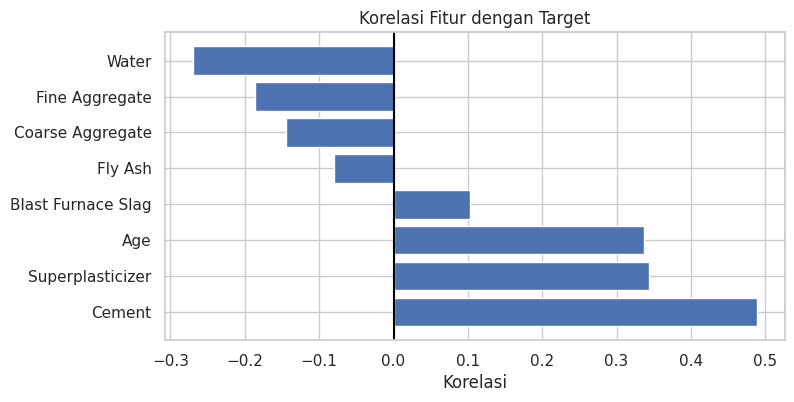

In [22]:
plt.figure(figsize=(8, 4))
plt.barh(corr_with_target.index, corr_with_target.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur dengan Target")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sisi positif berisi `Cement`, `Superplasticizer`, `Age`, dan `Blast Furnace Slag`. Sisi negatif berisi `Fly Ash`, `Coarse Aggregate`, `Fine Aggregate`, dan `Water`.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama target, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika target menurun.

### Buat scatter plot Cement dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan `Cement` dengan target.

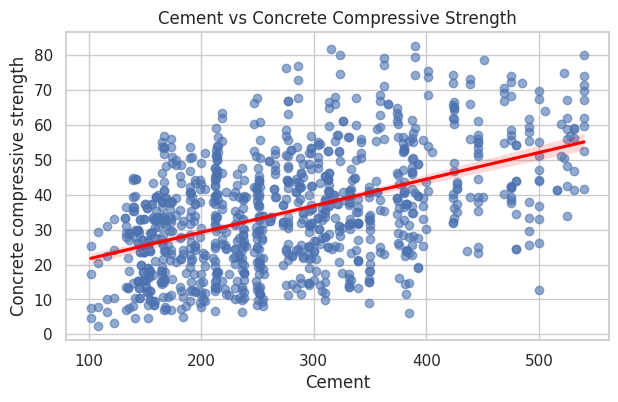

In [23]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="Cement",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Cement vs Concrete Compressive Strength")
plt.xlabel("Cement")
plt.ylabel("Concrete compressive strength")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `Cement` dengan target?

Jawaban: Semakin tinggi nilai `Cement`, nilai kuat tekan beton cenderung ikut meningkat, walaupun titik data masih menyebar.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **positif**.

### Buat plot rata-rata target berdasarkan Age

Gunakan line plot untuk melihat rata-rata kuat tekan beton pada setiap umur beton dalam satuan hari.

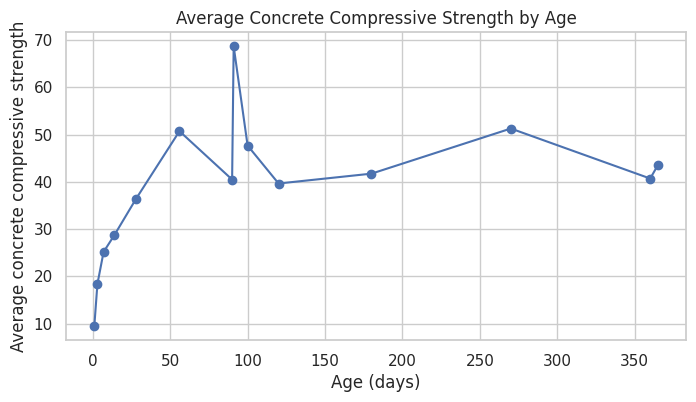

In [24]:
age_mean = df_clean.groupby("Age")[TARGET_COL].mean()

plt.figure(figsize=(8, 4))
plt.plot(age_mean.index, age_mean.values, marker="o")
plt.title("Average Concrete Compressive Strength by Age")
plt.xlabel("Age (days)")
plt.ylabel("Average concrete compressive strength")
plt.show()

> Berdasarkan line plot, bagaimana perubahan rata-rata target pada umur beton yang berbeda?

Jawaban: Rata-rata kuat tekan beton cenderung meningkat saat umur beton lebih lama.

> Apakah umur beton yang lebih lama selalu menaikkan target secara lurus?

Jawaban: Tidak selalu lurus sempurna, karena kenaikannya masih dapat berbeda pada beberapa kelompok umur beton.

## 6 - Feature dan Target

### Pisahkan fitur

Simpan semua kolom selain target ke variabel `X`.

In [25]:
X = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [26]:
y = df_clean[TARGET_COL]

### Tampilkan ukuran fitur

Cek ukuran `X` setelah fitur dipisahkan.

In [27]:
X.shape

(1005, 8)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki **1005 baris** dan **8 fitur**.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [28]:
y.shape

(1005,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **1005 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **1005**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [31]:
X_train.shape

(804, 8)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [32]:
X_test.shape

(201, 8)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **804 baris**, sedangkan data test memiliki **201 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **8 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [33]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [34]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [35]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [37]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [38]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [39]:
model.intercept_

np.float64(35.0669776119403)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **35.07**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [40]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
0,Cement,12.119
1,Blast Furnace Slag,8.437
7,Age,6.895
2,Fly Ash,5.440
4,Superplasticizer,1.971
6,Fine Aggregate,1.670
5,Coarse Aggregate,1.199
3,Water,-2.828


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `Cement` sekitar **12.12**, sedangkan koefisien negatif terbesar adalah `Water` sekitar **-2.83**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [41]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [42]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [43]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,19.010,23.460
1,24.290,16.703
2,26.320,22.452
3,34.570,37.396
4,44.130,42.885


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-5, dengan aktual **44.13** dan prediksi **42.89**. Prediksi paling jauh terlihat pada baris ke-2, dengan aktual **24.29** dan prediksi **16.70**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Beberapa prediksi cukup dekat dengan nilai aktual, tetapi ada juga prediksi yang memiliki selisih cukup besar.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [44]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

7.959910074856389

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [45]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

8.895256221464194

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **8.90 MPa**.

> Dalam satuan MPa, apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **8.90 MPa** dari nilai aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [46]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(10.001794718033251)

### Hitung RMSE test

Hitung RMSE pada data test.

In [47]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(11.191320210346136)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **11.19 MPa**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [48]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.6098668648171734

### Hitung R2 test

Hitung R2 Score pada data test.

In [49]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5801703029028777

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.58**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **58%** variasi target pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [50]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,7.960,10.002,0.610
1,Test,8.895,11.191,0.580


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih besar daripada MAE train, RMSE test lebih besar daripada RMSE train, dan R2 test lebih kecil daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **11.75%** lebih besar, RMSE test sekitar **11.89%** lebih besar, dan R2 test sekitar **4.87%** lebih kecil dibanding train. Perbedaannya tidak terlalu jauh, sehingga performa train dan test masih cukup seimbang.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

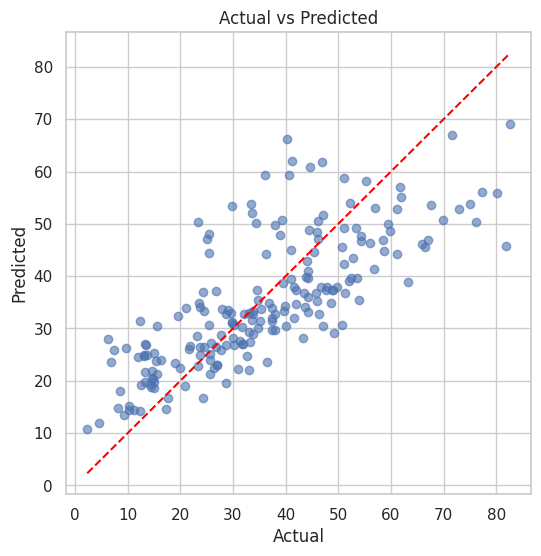

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Concrete Compressive Strength digunakan untuk memprediksi `Concrete compressive strength` berdasarkan komposisi bahan beton dan umur beton. Data tidak memiliki missing value dan memiliki **25** baris duplikat penuh. Setelah cleaning, dataset memiliki **1005** baris dan **9** kolom.

Hasil EDA menunjukkan bahwa `Cement`, `Superplasticizer`, dan `Age` memiliki hubungan positif dengan target, sedangkan `Water` cenderung memiliki hubungan negatif. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **8.90 MPa**, RMSE test sekitar **11.19 MPa**, dan R2 test sekitar **0.58**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **58%** variasi target pada data test dengan rata-rata error absolut sekitar **8.90 MPa**.